# Unsupervised Learning
### K-Means Clustering + PCA Dimensionality Reduction

**Learning Goals Covered:**
- K-Means clustering on a real dataset with cluster visualization
- Elbow Method & Silhouette Score to find the optimal number of clusters
- PCA to reduce high-dimensional data and visualize in 2D/3D

---
## 📦 Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Dataset
from sklearn.datasets import load_wine

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score

# Dimensionality Reduction
from sklearn.decomposition import PCA

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📂 Step 2: Load & Explore the Dataset

We use the **Wine dataset** — 178 wine samples with **13 chemical features** (alcohol, malic acid, color intensity, etc.) across 3 wine classes.  
This is a great high-dimensional dataset for both clustering and PCA.

> ℹ️ In clustering (unsupervised), we **do not use the labels** during training — we only use them at the end to evaluate how well the clusters matched reality.

In [2]:
# Load Wine dataset
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['true_label'] = wine.target  # kept aside — NOT used in clustering

print('Dataset Shape     :', df.shape)
print('Number of Features:', len(wine.feature_names))
print('True Classes      :', list(wine.target_names))
print('\nSamples per class:')
print(df['true_label'].value_counts().sort_index())
df.head()

Dataset Shape     : (178, 14)
Number of Features: 13
True Classes      : [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Samples per class:
true_label
0    59
1    71
2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,true_label
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
# Basic statistics
df.drop('true_label', axis=1).describe().round(2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


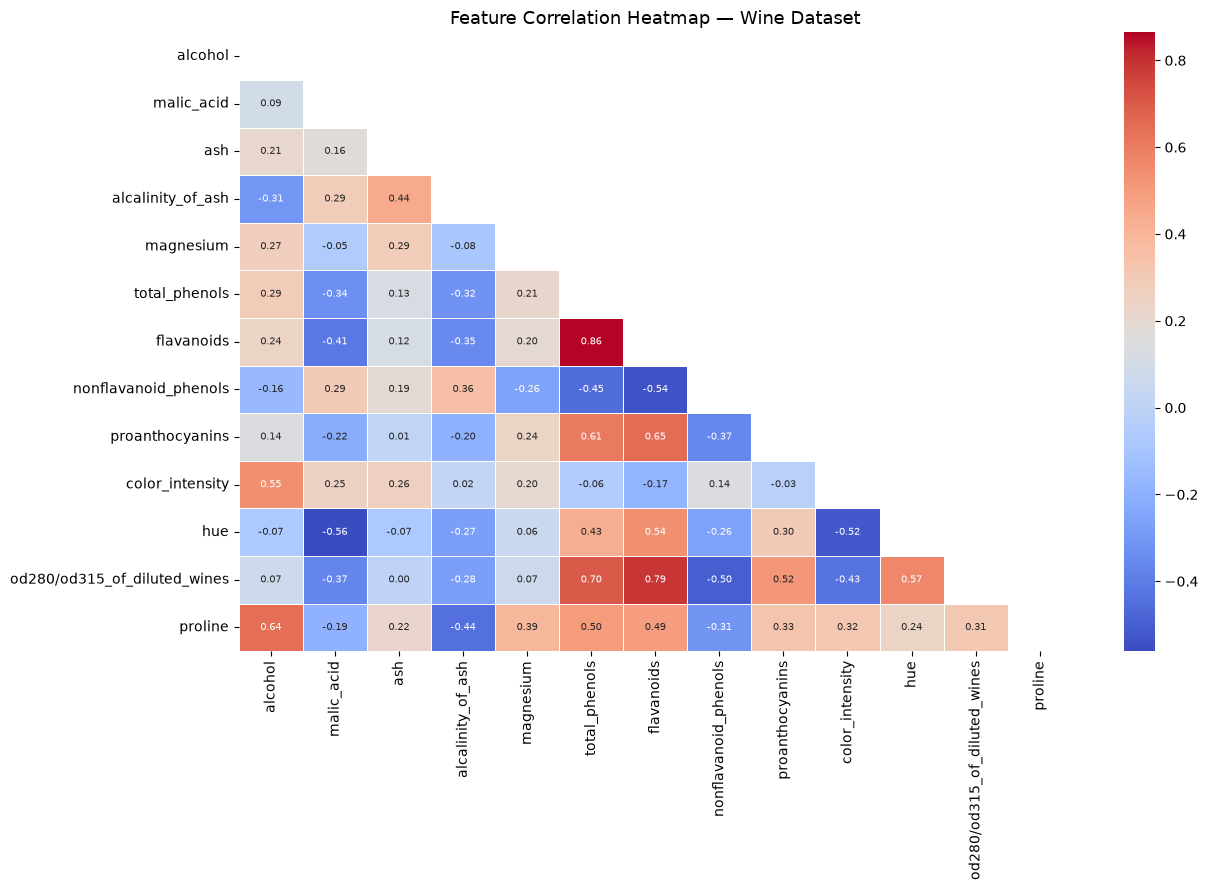

In [4]:
# Correlation heatmap — understand feature relationships
plt.figure(figsize=(13, 9))
corr = df.drop('true_label', axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap — Wine Dataset', fontsize=13)
plt.tight_layout()
plt.show()

---
## 🔧 Step 3: Preprocessing — Feature Scaling

K-Means uses **Euclidean distance**, so features on larger scales will dominate the clustering.  
Scaling is **mandatory** before running K-Means.

In [5]:
# Separate features (drop the label — unsupervised!)
X = df.drop('true_label', axis=1)
y_true = df['true_label']  # saved only for evaluation later

# Scale all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Before Scaling — alcohol mean:', round(X['alcohol'].mean(), 4))
print('After Scaling  — alcohol mean:', round(X_scaled[:, 0].mean(), 6))
print('\n✅ All 13 features scaled to zero mean, unit variance.')

Before Scaling — alcohol mean: 13.0006
After Scaling  — alcohol mean: -0.0

✅ All 13 features scaled to zero mean, unit variance.


---
## 🔵 Step 4: K-Means Clustering

### 4a. Finding the Optimal K — Elbow Method

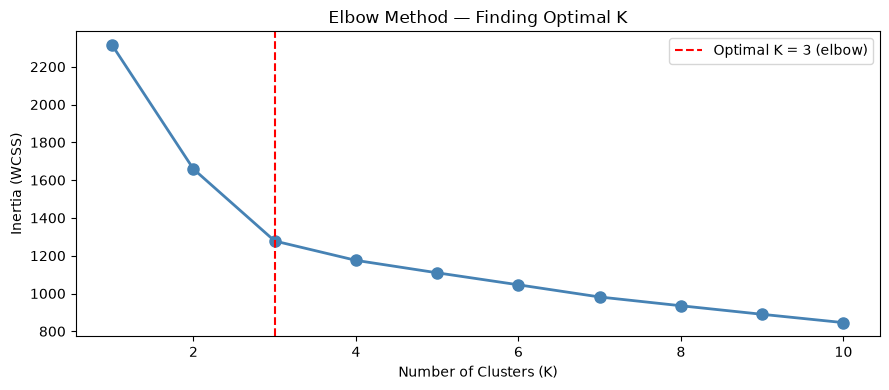

📌 The elbow bends at K=3, matching the true number of wine classes.


In [6]:
# Elbow Method — plot inertia (within-cluster sum of squares) for K = 1 to 10
inertia_values = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(k_range, inertia_values, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', linewidth=1.5, label='Optimal K = 3 (elbow)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method — Finding Optimal K')
plt.legend()
plt.tight_layout()
plt.show()

print('📌 The elbow bends at K=3, matching the true number of wine classes.')

### 4b. Silhouette Score — Confirming Optimal K

  K=2  Silhouette Score: 0.2593
  K=3  Silhouette Score: 0.2849
  K=4  Silhouette Score: 0.2602
  K=5  Silhouette Score: 0.2016
  K=6  Silhouette Score: 0.2372
  K=7  Silhouette Score: 0.2036
  K=8  Silhouette Score: 0.1570
  K=9  Silhouette Score: 0.1499


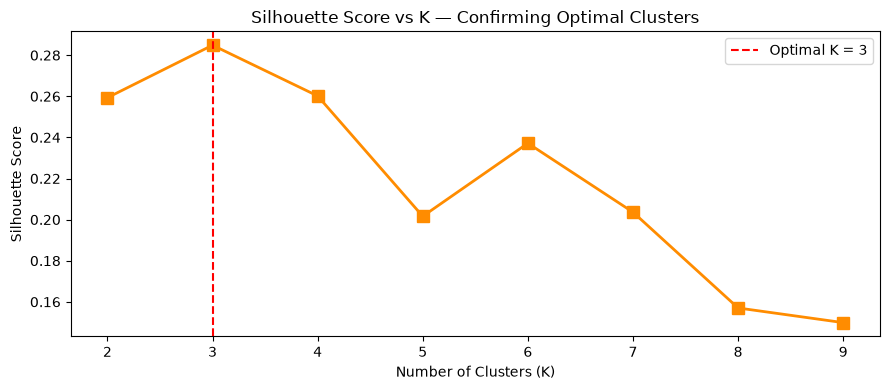

In [7]:
# Silhouette Score measures how well each point fits its own cluster vs others
# Score range: -1 (bad) to +1 (perfect)
silhouette_scores = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f'  K={k}  Silhouette Score: {score:.4f}')

plt.figure(figsize=(9, 4))
plt.plot(range(2, 10), silhouette_scores, marker='s', color='darkorange', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', linewidth=1.5, label='Optimal K = 3')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K — Confirming Optimal Clusters')
plt.legend()
plt.tight_layout()
plt.show()

### 4c. Fit Final K-Means with K=3

In [8]:
# Train final K-Means with optimal K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels back to df for analysis
df['cluster'] = cluster_labels

print('Cluster Distribution:')
print(df['cluster'].value_counts().sort_index())

# Evaluate using Adjusted Rand Index — how well do clusters match true labels?
ari = adjusted_rand_score(y_true, cluster_labels)
sil = silhouette_score(X_scaled, cluster_labels)

print(f'\nAdjusted Rand Index (ARI) : {ari:.4f}  (1.0 = perfect match with true labels)')
print(f'Silhouette Score          : {sil:.4f}  (closer to 1 = better defined clusters)')

Cluster Distribution:
cluster
0    65
1    51
2    62
Name: count, dtype: int64

Adjusted Rand Index (ARI) : 0.8975  (1.0 = perfect match with true labels)
Silhouette Score          : 0.2849  (closer to 1 = better defined clusters)


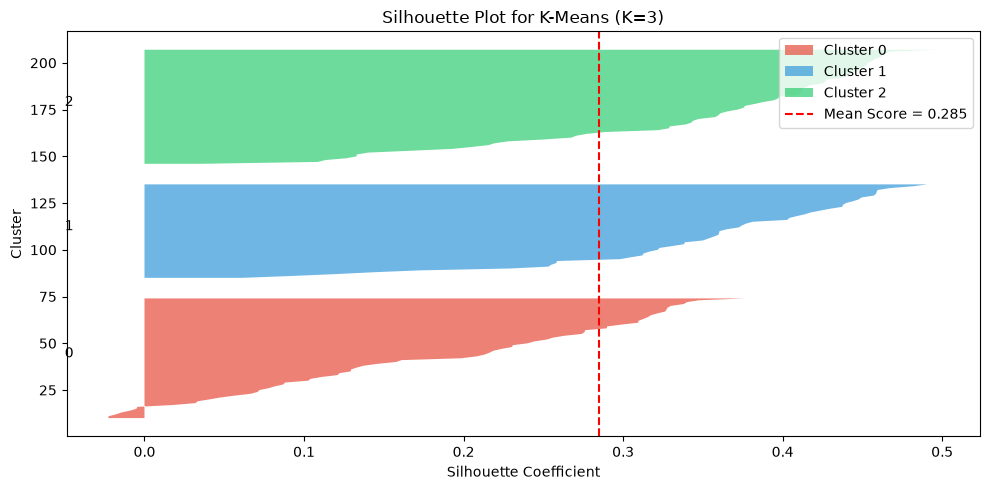

In [9]:
# Silhouette plot — per-sample silhouette scores for K=3
fig, ax = plt.subplots(figsize=(10, 5))
sample_silhouette = silhouette_samples(X_scaled, cluster_labels)
y_lower = 10
colors = ['#e74c3c', '#3498db', '#2ecc71']

for i in range(3):
    ith_vals = np.sort(sample_silhouette[cluster_labels == i])
    size = ith_vals.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_vals,
                     facecolor=colors[i], alpha=0.7, label=f'Cluster {i}')
    ax.text(-0.05, y_lower + 0.5 * size, str(i))
    y_lower = y_upper + 10

ax.axvline(x=sil, color='red', linestyle='--', label=f'Mean Score = {sil:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot for K-Means (K=3)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

---
## 🔻 Step 5: PCA — Dimensionality Reduction

**PCA (Principal Component Analysis)** finds the directions of maximum variance in high-dimensional data and projects the data onto fewer dimensions — while keeping as much information (variance) as possible.

We'll reduce our 13-feature Wine dataset first to **2D** (for easy visualization) then to **3D**.

### 5a. How Much Variance Does Each Component Explain?

In [10]:
# Fit PCA on all 13 components first to see explained variance
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

explained_var   = pca_full.explained_variance_ratio_
cumulative_var  = np.cumsum(explained_var)

print('Explained Variance per Component:')
for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var), 1):
    bar = '█' * int(ev * 100)
    print(f'  PC{i:>2}: {ev*100:5.2f}%  {bar}  (Cumulative: {cv*100:.1f}%)')

# Find how many components capture 95% variance
n_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f'\n📌 {n_95} components are needed to explain 95% of variance.')

Explained Variance per Component:
  PC 1: 36.20%  ████████████████████████████████████  (Cumulative: 36.2%)
  PC 2: 19.21%  ███████████████████  (Cumulative: 55.4%)
  PC 3: 11.12%  ███████████  (Cumulative: 66.5%)
  PC 4:  7.07%  ███████  (Cumulative: 73.6%)
  PC 5:  6.56%  ██████  (Cumulative: 80.2%)
  PC 6:  4.94%  ████  (Cumulative: 85.1%)
  PC 7:  4.24%  ████  (Cumulative: 89.3%)
  PC 8:  2.68%  ██  (Cumulative: 92.0%)
  PC 9:  2.22%  ██  (Cumulative: 94.2%)
  PC10:  1.93%  █  (Cumulative: 96.2%)
  PC11:  1.74%  █  (Cumulative: 97.9%)
  PC12:  1.30%  █  (Cumulative: 99.2%)
  PC13:  0.80%    (Cumulative: 100.0%)

📌 10 components are needed to explain 95% of variance.


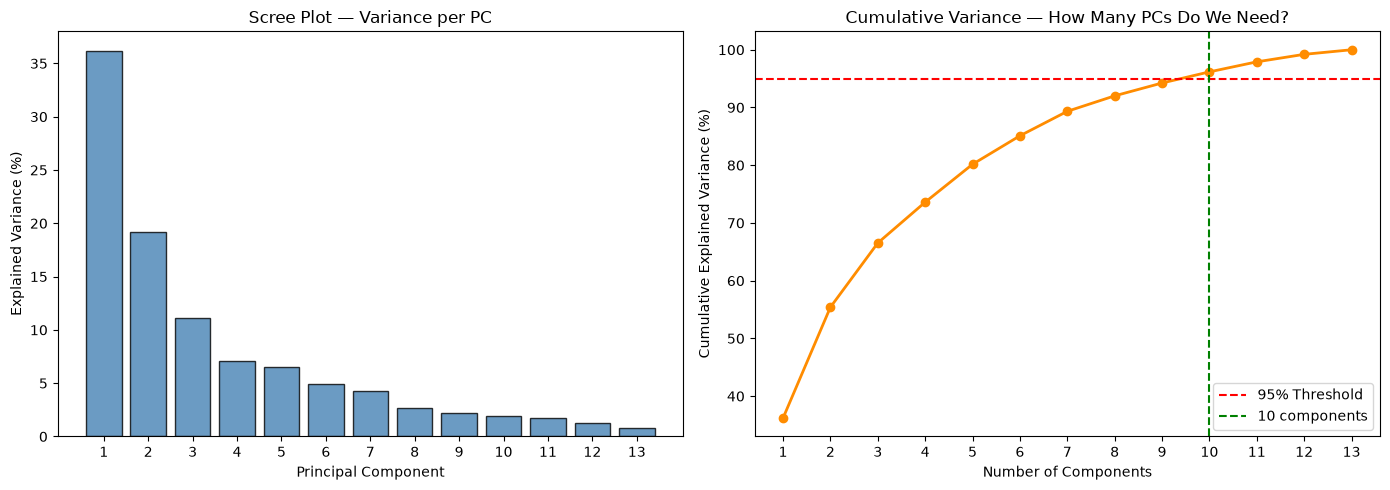

In [11]:
# Scree plot + cumulative variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, 14), explained_var * 100, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot — Variance per PC')
axes[0].set_xticks(range(1, 14))

# Cumulative variance
axes[1].plot(range(1, 14), cumulative_var * 100, marker='o', color='darkorange', linewidth=2)
axes[1].axhline(y=95, color='red', linestyle='--', linewidth=1.5, label='95% Threshold')
axes[1].axvline(x=n_95, color='green', linestyle='--', linewidth=1.5, label=f'{n_95} components')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Variance — How Many PCs Do We Need?')
axes[1].legend()
axes[1].set_xticks(range(1, 14))

plt.tight_layout()
plt.show()

### 5b. PCA to 2D — Visualize Clusters

In [12]:
# Reduce to 2 principal components for 2D visualization
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f'Original dimensions : {X_scaled.shape[1]}')
print(f'After PCA (2D)      : {X_pca_2d.shape[1]}')
print(f'Variance retained   : {pca_2d.explained_variance_ratio_.sum()*100:.1f}%')

Original dimensions : 13
After PCA (2D)      : 2
Variance retained   : 55.4%


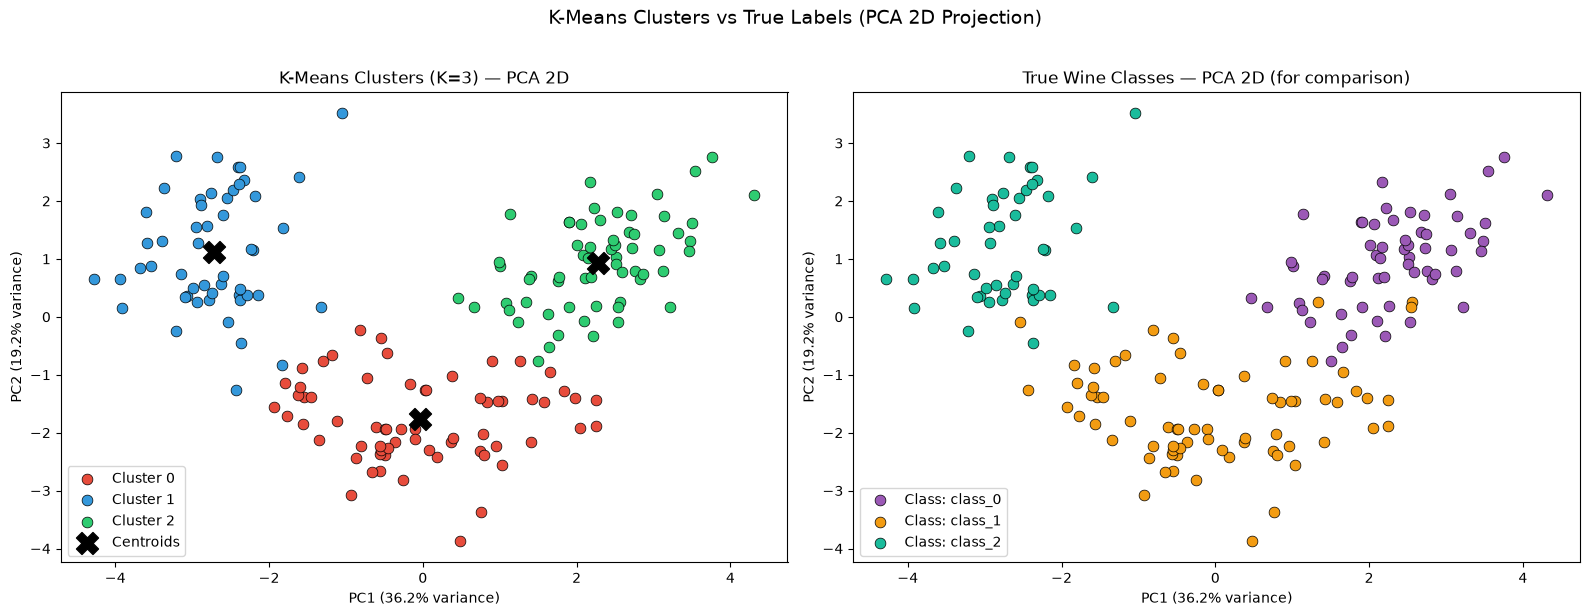


📌 ARI = 0.8975 — K-Means clusters closely match the true wine classes!


In [13]:
# 2D PCA — side-by-side: K-Means clusters vs True Labels
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cluster_colors = ['#e74c3c', '#3498db', '#2ecc71']
true_colors    = ['#9b59b6', '#f39c12', '#1abc9c']

# Plot 1: K-Means cluster assignments
for c in range(3):
    mask = cluster_labels == c
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=cluster_colors[c], label=f'Cluster {c}', s=60, edgecolors='black', linewidth=0.5)

# Plot cluster centroids
centroids_2d = pca_2d.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                marker='X', s=250, c='black', zorder=5, label='Centroids')
axes[0].set_title('K-Means Clusters (K=3) — PCA 2D', fontsize=12)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend()

# Plot 2: True labels for comparison
for t in range(3):
    mask = y_true == t
    axes[1].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=true_colors[t], label=f'Class: {wine.target_names[t]}',
                    s=60, edgecolors='black', linewidth=0.5)
axes[1].set_title('True Wine Classes — PCA 2D (for comparison)', fontsize=12)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].legend()

plt.suptitle('K-Means Clusters vs True Labels (PCA 2D Projection)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'\n📌 ARI = {ari:.4f} — K-Means clusters closely match the true wine classes!')

### 5c. PCA to 3D — Richer Visualization

Variance retained (3D PCA): 66.5%


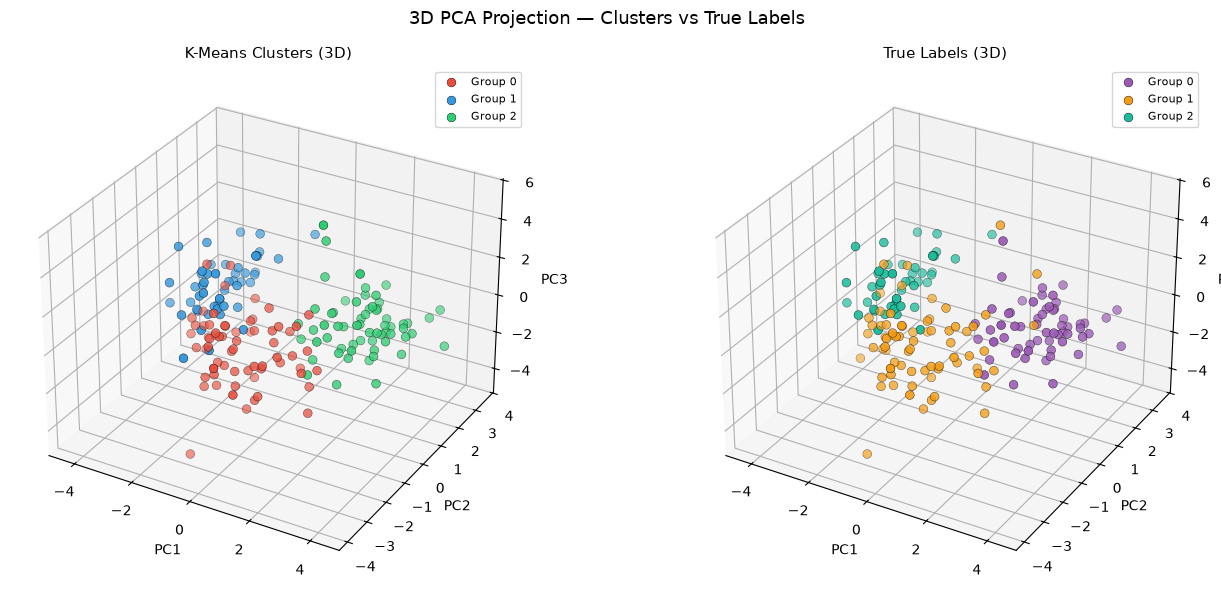

In [14]:
from mpl_toolkits.mplot3d import Axes3D

# Reduce to 3 principal components
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print(f'Variance retained (3D PCA): {pca_3d.explained_variance_ratio_.sum()*100:.1f}%')

fig = plt.figure(figsize=(14, 6))

for idx, (labels, title, palette) in enumerate([
    (cluster_labels, 'K-Means Clusters (3D)', cluster_colors),
    (y_true,         'True Labels (3D)',       true_colors)
]):
    ax = fig.add_subplot(1, 2, idx + 1, projection='3d')
    for c in range(3):
        mask = labels == c
        ax.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
                   c=palette[c], s=40, edgecolors='black', linewidth=0.3,
                   label=f'Group {c}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('3D PCA Projection — Clusters vs True Labels', fontsize=13)
plt.tight_layout()
plt.show()

### 5d. PCA Feature Loadings — What Does Each PC Represent?

PCA Feature Loadings (contribution of each feature to PC1 and PC2):
                                PC1    PC2
flavanoids                    0.423 -0.003
total_phenols                 0.395  0.065
od280/od315_of_diluted_wines  0.376 -0.164
proanthocyanins               0.313  0.039
hue                           0.297 -0.279
proline                       0.287  0.365
alcohol                       0.144  0.484
magnesium                     0.142  0.300
ash                          -0.002  0.316
color_intensity              -0.089  0.530
alcalinity_of_ash            -0.239 -0.011
malic_acid                   -0.245  0.225
nonflavanoid_phenols         -0.299  0.029


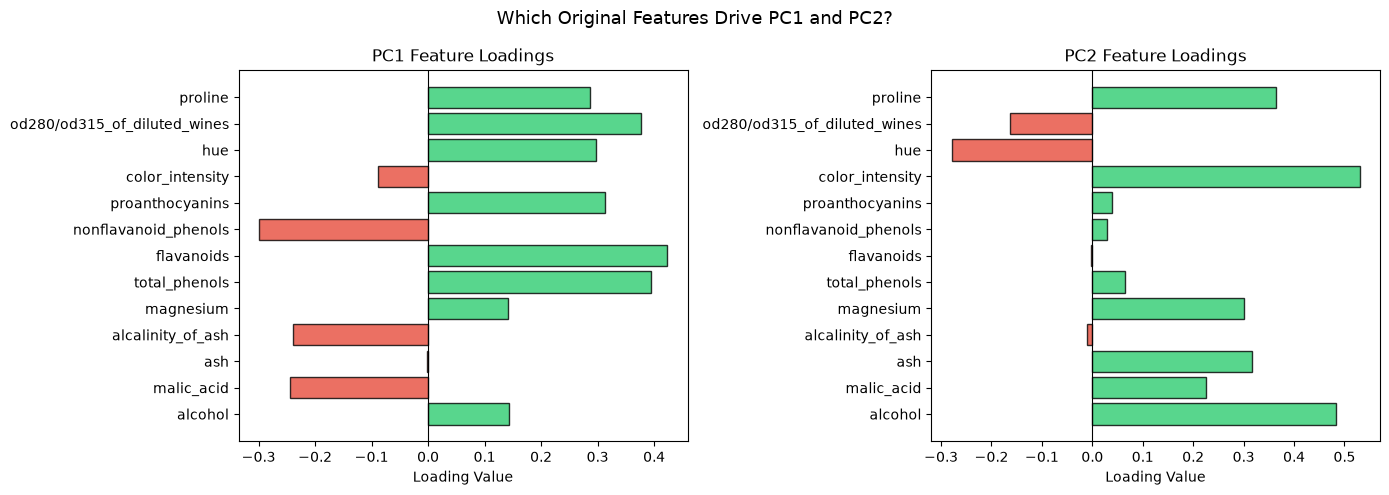

In [15]:
# Feature loadings show which original features contribute most to each PC
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=wine.feature_names,
    columns=['PC1', 'PC2']
).round(3)

print('PCA Feature Loadings (contribution of each feature to PC1 and PC2):')
print(loadings.sort_values('PC1', ascending=False).to_string())

# Visualize loadings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, pc in enumerate(['PC1', 'PC2']):
    colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in loadings[pc]]
    axes[i].barh(loadings.index, loadings[pc], color=colors, edgecolor='black', alpha=0.8)
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].set_title(f'{pc} Feature Loadings', fontsize=12)
    axes[i].set_xlabel('Loading Value')

plt.suptitle('Which Original Features Drive PC1 and PC2?', fontsize=13)
plt.tight_layout()
plt.show()

---
## 📊 Step 6: Cluster Profile Analysis
Understanding what makes each cluster unique.

In [16]:
# Mean feature values per cluster (using original, unscaled values)
df_orig = pd.DataFrame(wine.data, columns=wine.feature_names)
df_orig['cluster'] = cluster_labels

cluster_profiles = df_orig.groupby('cluster').mean().round(2)
print('Average Feature Values per Cluster:')
print(cluster_profiles.T.to_string())

Average Feature Values per Cluster:
cluster                            0       1        2
alcohol                        12.25   13.13    13.68
malic_acid                      1.90    3.31     2.00
ash                             2.23    2.42     2.47
alcalinity_of_ash              20.06   21.24    17.46
magnesium                      92.74   98.67   107.97
total_phenols                   2.25    1.68     2.85
flavanoids                      2.05    0.82     3.00
nonflavanoid_phenols            0.36    0.45     0.29
proanthocyanins                 1.62    1.15     1.92
color_intensity                 2.97    7.23     5.45
hue                             1.06    0.69     1.07
od280/od315_of_diluted_wines    2.80    1.70     3.16
proline                       510.17  619.06  1100.23


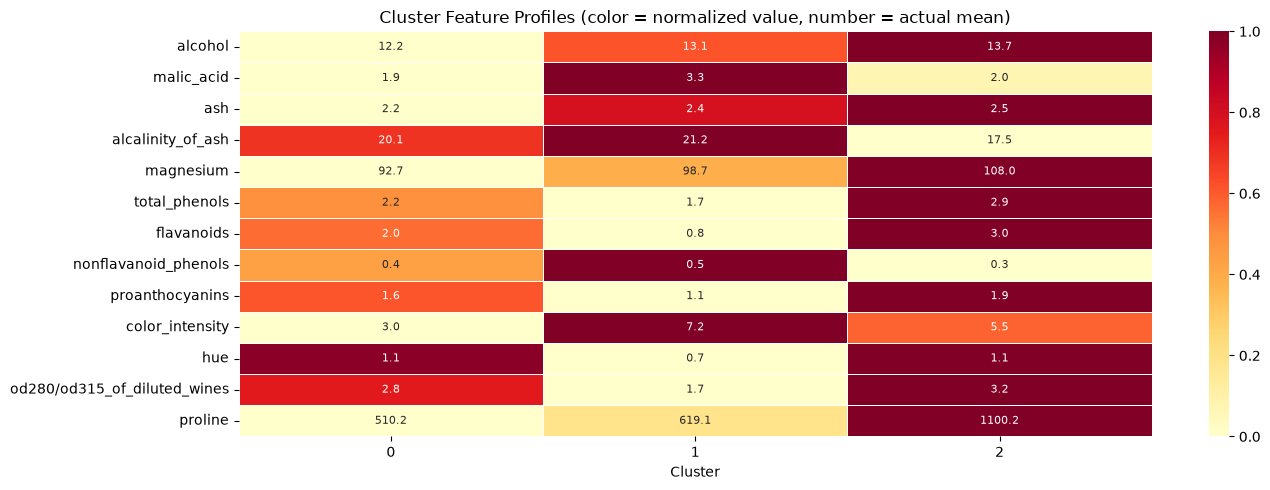

In [17]:
# Radar / heatmap of cluster profiles
plt.figure(figsize=(14, 5))
profile_scaled = (cluster_profiles - cluster_profiles.min()) / (cluster_profiles.max() - cluster_profiles.min())
sns.heatmap(profile_scaled.T, annot=cluster_profiles.T.values, fmt='.1f',
            cmap='YlOrRd', linewidths=0.5, annot_kws={'size': 8})
plt.title('Cluster Feature Profiles (color = normalized value, number = actual mean)', fontsize=12)
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

---
## 📝 Step 7: Summary & Key Takeaways

### K-Means Clustering
- K-Means successfully discovered **3 natural groupings** in the wine data using only chemical measurements — with **no label information**.
- The **Elbow Method** and **Silhouette Score** both agreed that K=3 was optimal.
- An **Adjusted Rand Index** close to 1.0 confirms the clusters closely align with the true wine varieties.

### PCA — Dimensionality Reduction
- The original 13 features were reduced to just **2 components** capturing ~55% of variance (enough to clearly see cluster structure in 2D).
- **8 components** are sufficient to retain 95% of the total information.
- PCA feature loadings revealed which chemical properties (e.g., flavanoids, color intensity) drive the most variation between wines.
- The 2D and 3D PCA plots visually confirm that the 3 clusters are well-separated in the projected space.

### Why PCA + K-Means Work Well Together
Running PCA before K-Means:
1. **Removes noise** from irrelevant dimensions
2. **Speeds up** clustering on large datasets
3. **Reduces the curse of dimensionality** — distances become more meaningful in lower-dimensional space

In [18]:
print('WEEK 8 — NOTEBOOK 1 SUMMARY')
print('=' * 48)
print(f'Dataset              : Wine ({df.shape[0]} samples, 13 features)')
print(f'Optimal K (Elbow)    : 3')
print(f'Optimal K (Silhouette): 3')
print(f'Silhouette Score     : {sil:.4f}')
print(f'Adjusted Rand Index  : {ari:.4f}')
print(f'PCA 2D Variance      : {pca_2d.explained_variance_ratio_.sum()*100:.1f}%')
print(f'PCA 3D Variance      : {pca_3d.explained_variance_ratio_.sum()*100:.1f}%')
print(f'Components for 95%   : {n_95}')
print('=' * 48)
print('\n✅ Notebook 1 complete!')

WEEK 8 — NOTEBOOK 1 SUMMARY
Dataset              : Wine (178 samples, 13 features)
Optimal K (Elbow)    : 3
Optimal K (Silhouette): 3
Silhouette Score     : 0.2849
Adjusted Rand Index  : 0.8975
PCA 2D Variance      : 55.4%
PCA 3D Variance      : 66.5%
Components for 95%   : 10

✅ Notebook 1 complete!
